In [1]:
import matplotlib.pyplot as plt
import numpy as np

import scienceplots
plt.style.use('science')

import matplotlib as mpl
from matplotlib.lines import Line2D
mpl.rcParams['figure.dpi'] = 300

In [2]:
k_min, k_max   = 2., 45
k_smooth_array = np.logspace(np.log10(k_min), np.log10(k_max), num=10)

In [3]:
field  = 'Mtot'
logE_A = np.load(f'results/{field}_log_evidence_Astrid_CV.npy')
logE_I = np.load(f'results/{field}_log_evidence_IllustrisTNG_CV.npy')
logE_S = np.load(f'results/{field}_log_evidence_SIMBA_CV.npy')


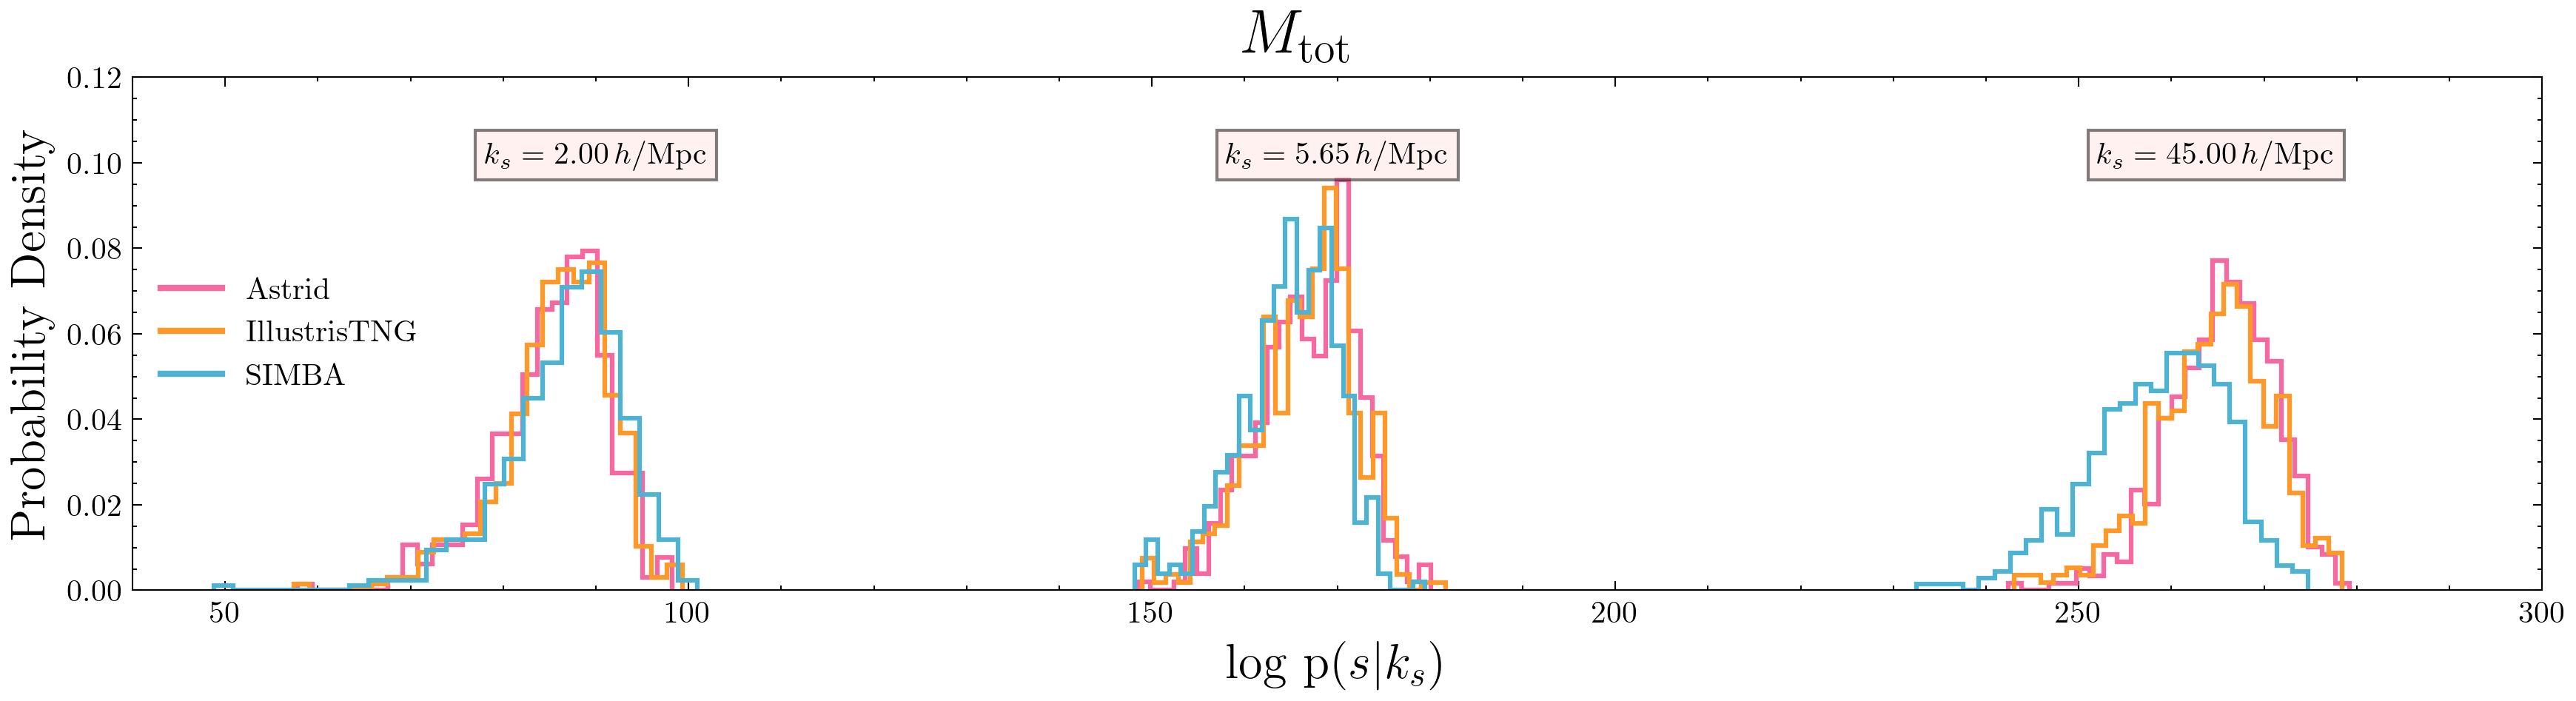

In [4]:
f, ax = plt.subplots(1, 1, sharey=True, figsize=(14, 3))
f.suptitle(r'$M_{\mathrm{tot}}$', fontsize=20)
colors  = ['#f768a1', '#fe9929', '#4eb3d3',] #['mediumvioletred', 'seagreen', 'steelblue']
lstyles = ['dashdot', 'dashed', 'solid']
offsets = [0, 100, 200]
k_idxs  = [0, 3, 9]
n_bins  = 25

for i, k_idx in enumerate(k_idxs):
    ax.hist(logE_A[k_idx] + offsets[i], bins=n_bins, 
            ec=colors[0], fc='none', lw=1.5, histtype='step', density=True,
           )
    ax.hist(logE_I[k_idx] + offsets[i], bins=n_bins,
            ec=colors[1], fc='none', lw=1.5, histtype='step', density=True,
           )
    ax.hist(logE_S[k_idx] + offsets[i], bins=n_bins, 
            ec=colors[2], fc='none', lw=1.5, histtype='step', density=True,
           )    

custom_lines = [Line2D([0], [0], color=colors[0], lw=2),
                Line2D([0], [0], color=colors[1], lw=2),
                Line2D([0], [0], color=colors[2], lw=2),]

ax.legend(custom_lines, ['Astrid', 'IllustrisTNG', 'SIMBA',], loc='center left')

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='square', facecolor='mistyrose', alpha=0.5)
ax.text(78, 0.1, r'$ k_s ={:.2f} \, h/$'.format(k_smooth_array[k_idxs[0]])+r'$\mathrm{Mpc}$',
        bbox=props)
ax.text(158, 0.1, r'$ k_s ={:.2f} \, h/$'.format(k_smooth_array[k_idxs[1]])+r'$\mathrm{Mpc}$',
        bbox=props)
ax.text(252, 0.1, r'$ k_s ={:.2f} \, h/$'.format(k_smooth_array[k_idxs[2]])+r'$\mathrm{Mpc}$',
       bbox=props)

ax.set_ylabel('Probability Density', fontsize=16)
ax.set_xlabel('log p' + r'$(s|k_{s})$', fontsize=16)
ax.set_xlim(40, 300)
ax.set_ylim(0., 0.12)
plt.savefig(f'plots/3_evidence_{field}_single_plot.pdf')
f.show()